In [82]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [83]:
!kaggle competitions download dogs-vs-cats

dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [84]:
!ls

 dogs-vs-cats.zip   kaggle.json   sampleSubmission.csv	 train
'image resized'     sample_data   test1.zip		 train.zip


In [85]:
from zipfile import ZipFile
file_name = 'dogs-vs-cats.zip'

with ZipFile(file_name,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [86]:
from zipfile import ZipFile
file_name = 'train.zip'

with ZipFile(file_name,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [87]:
import os
# counting the number of files in train folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


os হলো Python-এর built-in module।
এটি ফাইল, ফোল্ডার এবং operating system-এর সাথে কাজ করার জন্য ব্যবহৃত হয়।

os.walk('/content/train') একটি generator return করে, next() ব্যবহার করা হয়েছে কারণ os.walk() generator return করে। next() প্রথম result নিয়ে আসে।


যা প্রতিটি directory-এর জন্য ৩টি জিনিস দেয়:

path → বর্তমান folder-এর path

dirs → সেই folder-এর subfolder-এর list

files → সেই folder-এর file-এর list


In [88]:
file_names = os.listdir('/content/train/')
print(file_names)

['cat.11042.jpg', 'cat.4615.jpg', 'cat.9447.jpg', 'dog.8850.jpg', 'cat.11019.jpg', 'cat.1359.jpg', 'cat.6061.jpg', 'cat.6765.jpg', 'cat.6088.jpg', 'dog.8153.jpg', 'cat.6309.jpg', 'dog.7900.jpg', 'cat.2445.jpg', 'dog.10165.jpg', 'dog.8304.jpg', 'dog.8126.jpg', 'dog.2296.jpg', 'cat.1210.jpg', 'cat.4278.jpg', 'dog.10584.jpg', 'cat.12067.jpg', 'dog.432.jpg', 'cat.12291.jpg', 'cat.5643.jpg', 'cat.7835.jpg', 'cat.948.jpg', 'dog.9917.jpg', 'dog.5857.jpg', 'cat.11430.jpg', 'dog.200.jpg', 'dog.10609.jpg', 'cat.4366.jpg', 'dog.2283.jpg', 'cat.10020.jpg', 'cat.9262.jpg', 'cat.8086.jpg', 'cat.1504.jpg', 'dog.10530.jpg', 'cat.5876.jpg', 'cat.506.jpg', 'dog.11606.jpg', 'cat.6566.jpg', 'dog.10348.jpg', 'cat.3487.jpg', 'cat.5591.jpg', 'dog.506.jpg', 'cat.4587.jpg', 'dog.8872.jpg', 'cat.7221.jpg', 'cat.8826.jpg', 'dog.9090.jpg', 'cat.3551.jpg', 'cat.7186.jpg', 'dog.730.jpg', 'dog.967.jpg', 'cat.3494.jpg', 'cat.6556.jpg', 'dog.4853.jpg', 'dog.9296.jpg', 'cat.6255.jpg', 'cat.6635.jpg', 'dog.2805.jpg', 'd

In [89]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

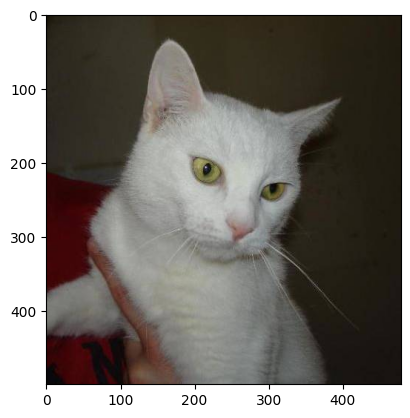

In [90]:
# display cat image
img = mpimg.imread('/content/train/cat.11042.jpg')
imgplt = plt.imshow(img)
plt.show()

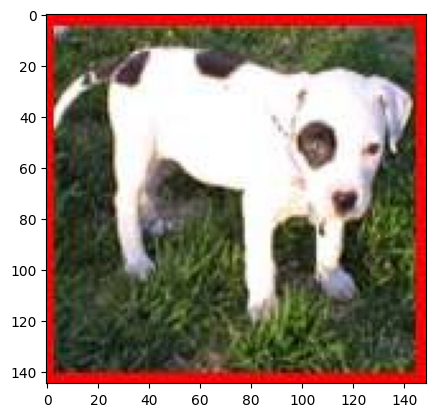

In [91]:
# display dog image
img = mpimg.imread('/content/train/dog.8850.jpg')
imgplt = plt.imshow(img)
plt.show()

In [92]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name = file_names[i]
  print(name[0:3])



cat
cat
cat
dog
cat


In [93]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


Resizing all the Images

eita code thik ache just 2 ber same e folder create korte chaichi tai wrong diche

In [149]:
#creating a directory for resized images
os.mkdir('/content/image resized')

FileExistsError: [Errno 17] File exists: '/content/image resized'

In [98]:
original_folder = '/content/train/'
resized_folder = '/content/image resized/'

for i in range(2000):

  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

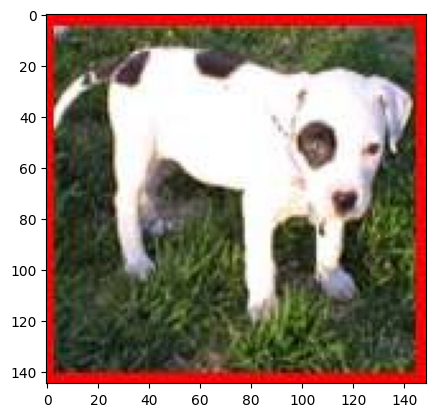

In [99]:
# display dog image
img = mpimg.imread('/content/train/dog.8850.jpg')
imgplt = plt.imshow(img)
plt.show()

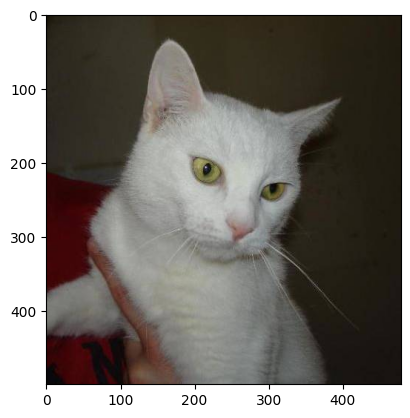

In [100]:
# display cat image
img = mpimg.imread('/content/train/cat.11042.jpg')
imgplt = plt.imshow(img)
plt.show()

**Creating labels for resized images of dogs and cats**

Cat --> 0

Dog --> 1

In [101]:
# creaing a for loop to assign labels
filenames = os.listdir('/content/image resized/')


labels = []

for i in range(2000):

  file_name = filenames[i]
  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [102]:
print(filenames[0:5])
print(len(filenames))

['cat.11042.jpg', 'cat.4615.jpg', 'cat.9447.jpg', 'dog.8850.jpg', 'cat.11019.jpg']
2000


In [103]:
print(labels[0:5])
print(len(labels))

[0, 0, 0, 1, 0]
2000


In [104]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1033  967]


Converting all the resized images to numpy arrays

In [105]:
import cv2
import glob

In [106]:
image_directory = '/content/image resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [107]:
print(dog_cat_images)

[[[[  6  18  22]
   [  8  20  24]
   [ 11  23  27]
   ...
   [ 16  28  32]
   [ 16  28  32]
   [ 16  28  32]]

  [[  7  19  23]
   [  9  21  25]
   [ 12  24  28]
   ...
   [ 16  28  32]
   [ 16  28  32]
   [ 16  28  32]]

  [[  8  20  24]
   [ 10  22  26]
   [ 13  25  29]
   ...
   [ 16  28  32]
   [ 16  28  32]
   [ 16  28  32]]

  ...

  [[ 13   5  16]
   [ 13   5  15]
   [ 14   7  14]
   ...
   [ 16  19  24]
   [ 16  19  24]
   [ 16  19  24]]

  [[ 14   3  19]
   [ 14   4  17]
   [ 13   5  15]
   ...
   [ 16  19  24]
   [ 16  19  24]
   [ 16  19  24]]

  [[ 14   2  20]
   [ 13   2  18]
   [ 12   4  14]
   ...
   [ 16  19  24]
   [ 16  19  24]
   [ 16  19  24]]]


 [[[  0  78 155]
   [  6  92 162]
   [ 14 111 169]
   ...
   [ 40   5 139]
   [ 39   0 155]
   [ 70  26 193]]

  [[  0  83 158]
   [  7  96 163]
   [ 18 115 171]
   ...
   [ 45  11 142]
   [ 44   3 155]
   [ 73  28 191]]

  [[  0  87 154]
   [  6  99 162]
   [ 15 117 169]
   ...
   [ 57  19 148]
   [ 52   7 157]
   [ 77  32

In [108]:
type(dog_cat_images)

numpy.ndarray

In [109]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [110]:
X = dog_cat_images
Y = np.asarray(labels)

In [111]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [112]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


In [113]:
# scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [114]:
print(X_train_scaled)

[[[[0.70196078 0.76862745 0.75686275]
   [0.56078431 0.62745098 0.61568627]
   [0.53333333 0.6        0.58823529]
   ...
   [0.47058824 0.52941176 0.51372549]
   [0.47058824 0.53333333 0.50588235]
   [0.47058824 0.53333333 0.50588235]]

  [[0.70196078 0.76862745 0.75686275]
   [0.56862745 0.63529412 0.62352941]
   [0.5372549  0.60392157 0.59215686]
   ...
   [0.47058824 0.52941176 0.51372549]
   [0.47058824 0.53333333 0.50588235]
   [0.47058824 0.53333333 0.50588235]]

  [[0.70196078 0.77254902 0.76862745]
   [0.57254902 0.64313725 0.63921569]
   [0.50980392 0.58039216 0.57647059]
   ...
   [0.47058824 0.52941176 0.51372549]
   [0.47058824 0.53333333 0.50588235]
   [0.47058824 0.53333333 0.50588235]]

  ...

  [[0.83137255 0.85490196 0.8745098 ]
   [0.83137255 0.85490196 0.8745098 ]
   [0.83137255 0.85490196 0.8745098 ]
   ...
   [0.48627451 0.52941176 0.52156863]
   [0.47058824 0.51372549 0.50588235]
   [0.45882353 0.50196078 0.49411765]]

  [[0.83137255 0.85490196 0.8745098 ]
   [0.8

Building the Neural Network

In [129]:
import tensorflow as tf
import tensorflow_hub as hub

In [139]:
import tf_keras as keras

In [140]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [143]:
num_of_classes = 2

model = keras.Sequential([
    pretrained_model,
    keras.layers.Dense(num_of_classes)
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_11 (KerasLayer  (None, 1280)              2257984   
 )                                                               
                                                                 
 dense_2 (Dense)             (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [134]:
print(tf.__version__)
print(hub.__version__)

2.20.0
0.16.1


In [144]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [145]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 77s 1s/step - loss: 0.2381 - acc: 0.8925
Epoch 2/5
50/50 [==============================] - 59s 1s/step - loss: 0.0757 - acc: 0.9712
Epoch 3/5
50/50 [==============================] - 58s 1s/step - loss: 0.0525 - acc: 0.9850
Epoch 4/5
50/50 [==============================] - 62s 1s/step - loss: 0.0417 - acc: 0.9894
Epoch 5/5
50/50 [==============================] - 59s 1s/step - loss: 0.0333 - acc: 0.9931


In [146]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 [==============================] - 16s 1s/step - loss: 0.0516 - acc: 0.9825
Test Loss = 0.05163908004760742
Test Accuracy = 0.9825000166893005


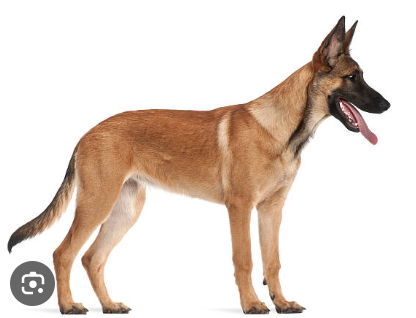

1/1 [==============================] - 1s 1s/step
[[-2.1100907  3.0731   ]]
1
The image represents a Dog


In [147]:
input_image_path = '/content/Screenshot 2026-07-02 024440.png'

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

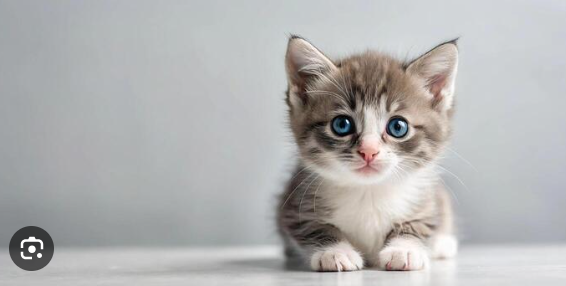

1/1 [==============================] - 0s 194ms/step
[[ 3.1375024 -3.363917 ]]
0
The image represents a Cat


In [148]:
input_image_path = '/content/Screenshot 2026-07-02 024603.png'

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')